# ERA5-Land na prática

**Curso rápido, passo a passo**, usando o arquivo `data_stream-moda.nc` que já está nesta pasta.

## O que você vai aprender

| # | Etapa | Ferramenta |
|---|-------|-----------|
| 1 | De onde vêm os dados (CDS / `cdsapi`) | — |
| 2 | Abrir o NetCDF e entender a estrutura | `xarray` |
| 3 | Descobrir variáveis, nomes longos e **unidades** | `xarray` + `pandas` |
| 4 | Descobrir o **período de estudo** | `xarray` |
| 5 | Converter unidades (K→°C, m→mm, u/v→vento) | `numpy` |
| 6 | **Recortar por coordenadas** (caixa e ponto) | `.sel()` |
| 7 | **Médias e somas** (temporal, espacial, ponderada) | `.mean()`, `.sum()` |
| 8 | Mapas | `matplotlib` |
| 9 | Exportar e **visualizar `.tif`** | `rioxarray` |
| 10 | **Séries temporais** em gráficos | `matplotlib` |
| 11 | Exportar resultados (CSV / NetCDF) | `pandas` / `xarray` |

> **Como usar:** rode as células na ordem (`Shift+Enter`). Cada bloco é independente o suficiente para você
> voltar e mexer nos parâmetros (cidades, região, variável) e rodar de novo.

## 0. Ambiente

Este notebook precisa de: `xarray`, `netCDF4`, `rioxarray`, `rasterio`, `matplotlib` e `pandas`.

In [2]:
!pip install rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.2 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [3]:
import pathlib

import numpy as np
import pandas as pd
import xarray as xr
import rioxarray  # registra o acessor .rio no xarray
import matplotlib.pyplot as plt

# --- estilo enxuto para todos os gráficos do notebook ---
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10,
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelcolor": "#52514e", "axes.edgecolor": "#c9c8c3",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e8e7e3", "grid.linewidth": 0.8,
    "xtick.color": "#52514e", "ytick.color": "#52514e", "text.color": "#0b0b0b",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "lines.linewidth": 2, "lines.markersize": 5,
})

# Paleta categórica (para séries): azul, laranja, verde-água — segura para daltonismo.
CORES = ["#2a78d6", "#eb6834", "#1baf7a"]
# Escalas contínuas: sequencial para magnitude, divergente para anomalia. Nunca "arco-íris"/jet.
CMAP_TEMP, CMAP_CHUVA, CMAP_ANOM = "YlOrRd", "Blues", "RdBu_r"

print("xarray    ", xr.__version__)
print("rioxarray ", rioxarray.__version__)
print("pandas    ", pd.__version__)
print("numpy     ", np.__version__)

xarray     2026.7.0
rioxarray  0.23.0
pandas     2.2.3
numpy      2.1.3


## 1. De onde vêm os dados

O **ERA5-Land** é uma reanálise do ECMWF: um modelo que reconstrói o passado do
clima combinando modelo + observações. Características que importam na prática:

* resolução espacial de **0,1° (~9 km)**;
* dados **horários desde 1950**, e produtos **mensais** derivados deles;
* cobre **apenas superfícies continentais** — sobre o oceano os valores são `NaN`.

O download é feito no **Climate Data Store (CDS)** da Copernicus: <https://cds.climate.copernicus.eu>.
Depois de criar a conta e salvar sua chave em `~/.cdsapirc`, o pedido é feito por código:

```python
import cdsapi

c = cdsapi.Client()
c.retrieve(
    "reanalysis-era5-land-monthly-means",
    {
        "product_type": "monthly_averaged_reanalysis",
        "variable": [
            "2m_temperature",
            "10m_u_component_of_wind",
            "10m_v_component_of_wind",
            "total_precipitation",
        ],
        "year": "2025",
        "month": [f"{m:02d}" for m in range(1, 13)],
        "time": "00:00",
        "area": [6, -74, -34, -34],   # Norte, Oeste, Sul, Leste
        "format": "netcdf",
    },
    "era5_land_2025.nc",
)
```

> **Por que o arquivo se chama `data_stream-moda.nc`?**
> O CDS entrega um GRIB e converte para NetCDF; `stream = moda` é o código do ECMWF para
> *monthly means of daily means* — **médias mensais**. Se você pedir vários produtos no mesmo
> request, vem um `.zip` com um arquivo por *stream*.

## 2. Abrir o arquivo com xarray

`xr.open_dataset()` lê o NetCDF **sem carregar tudo na memória**.

Só de mostrar o objeto `ds` você já tem um "raio-x" do arquivo.

In [4]:
CAMINHO = pathlib.Path("/content/data_stream-moda.nc")
SAIDAS = pathlib.Path("saidas")
SAIDAS.mkdir(exist_ok=True)

ds = xr.open_dataset(CAMINHO)
ds

<xarray.Dataset> Size: 31MB
Dimensions:     (valid_time: 12, latitude: 401, longitude: 401)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 96B 2025-01-01 ... 2025-12-01
    expver      (valid_time) <U4 192B ...
  * latitude    (latitude) float64 3kB 6.0 5.9 5.8 5.7 ... -33.8 -33.9 -34.0
  * longitude   (longitude) float64 3kB -74.0 -73.9 -73.8 ... -34.2 -34.1 -34.0
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 8MB ...
    u10         (valid_time, latitude, longitude) float32 8MB ...
    v10         (valid_time, latitude, longitude) float32 8MB ...
    tp          (valid_time, latitude, longitude) float32 8MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-02T16:39 GRIB to CDM+CF via cfgrib-0.9.1...

### Como ler esse "raio-x"

Um `Dataset` do xarray tem quatro partes:

* **Dimensions** — os eixos e seus tamanhos: aqui `valid_time=12`, `latitude=401`, `longitude=401`.
* **Coordinates** — os *rótulos* de cada eixo (as datas, as latitudes em graus...). É o que permite
  pedir "1º de março" ou "latitude −15,8" em vez de "posição 2" ou "posição 218".
* **Data variables** — as variáveis em si (`t2m`, `u10`, `v10`, `tp`), cada uma um cubo
  tempo × latitude × longitude.
* **Attributes** — metadados livres (quem produziu, convenção, histórico).

Cada variável isolada é um `DataArray` (`ds["t2m"]`), e é nele que a maior parte do trabalho acontece.

In [5]:
print("Dimensões:", dict(ds.sizes))
print("Coordenadas:", list(ds.coords))
print("Variáveis:", list(ds.data_vars))
print()
print("Resolução: %.2f° em latitude, %.2f° em longitude"
      % (abs(float(ds.latitude.diff("latitude")[0])), float(ds.longitude.diff("longitude")[0])))
print("Extensão: lat %.1f a %.1f | lon %.1f a %.1f"
      % (float(ds.latitude.max()), float(ds.latitude.min()),
         float(ds.longitude.min()), float(ds.longitude.max())))

Dimensões: {'valid_time': 12, 'latitude': 401, 'longitude': 401}
Coordenadas: ['number', 'valid_time', 'latitude', 'longitude', 'expver']
Variáveis: ['t2m', 'u10', 'v10', 'tp']

Resolução: 0.10° em latitude, 0.10° em longitude
Extensão: lat 6.0 a -34.0 | lon -74.0 a -34.0


## 3. Quais são as variáveis e as unidades

`tp` pode ser milímetros, metros ou taxa por segundo dependendo do produto.
A informação correta está em `.attrs` de cada variável — em geral nos campos `long_name` e `units`.

A célula abaixo monta uma tabelinha com tudo o que interessa.

In [6]:
tabela = pd.DataFrame([
    {
        "variável": nome,
        "descrição": ds[nome].attrs.get("long_name", "—"),
        "unidade": ds[nome].attrs.get("units", "—"),
        "dimensões": " × ".join(ds[nome].dims),
        "formato": str(ds[nome].shape),
        "tipo": str(ds[nome].dtype),
    }
    for nome in ds.data_vars
])
tabela

,variável,descrição,unidade,dimensões,formato,tipo
0,t2m,2 metre temperature,K,valid_time × latitude × longitude,"(12, 401, 401)",float32
1,u10,10 metre U wind component,m s**-1,valid_time × latitude × longitude,"(12, 401, 401)",float32
2,v10,10 metre V wind component,m s**-1,valid_time × latitude × longitude,"(12, 401, 401)",float32
3,tp,Total precipitation,m,valid_time × latitude × longitude,"(12, 401, 401)",float32


### Lendo as unidades deste arquivo

| Variável | Unidade no arquivo | O que significa | Unidade "de gente" |
|---|---|---|---|
| `t2m` | `K` | temperatura do ar a 2 m | °C = K − 273,15 |
| `u10` | `m s**-1` | componente **oeste→leste** do vento a 10 m | m/s |
| `v10` | `m s**-1` | componente **sul→norte** do vento a 10 m | m/s |
| `tp` | `m` | precipitação total | mm = m × 1000 |


No ERA5-Land a precipitação é *acumulada*.
> No produto de **médias mensais**, cada valor é a **média das acumulações diárias** — ou seja, a
> unidade `m` é na prática **metros por dia**. Para o total do mês: `tp × 1000 × dias_do_mês`.
> A checagem de sanidade está na próxima célula: se a média fosse "metros por mês", daríamos
> ~1,6 mm de chuva por mês na Amazônia — absurdo.

In [7]:
media_tp = float(ds["tp"].mean())
print("Média de tp no arquivo: %.6f m" % media_tp)
print("  lendo como m/dia  →  %6.2f mm/dia   → %7.0f mm/ano" % (media_tp * 1000, media_tp * 1000 * 365))
print("  lendo como m/mês   →  %6.2f mm/mês  → %7.1f mm/ano" % (media_tp * 1000, media_tp * 1000 * 12))

Média de tp no arquivo: 0.004365 m
  lendo como m/dia  →    4.36 mm/dia   →    1593 mm/ano
  lendo como m/mês   →    4.36 mm/mês  →    52.4 mm/ano


## 4. Qual é o período de estudo

O eixo temporal aqui se chama `valid_time` (nomes comuns em outros arquivos: `time`, `date`,
`forecast_reference_time`). O acessor **`.dt`** dá acesso a ano, mês, dia, nome do mês, dias do mês etc.,
igual ao pandas.

In [8]:
tempo = ds["valid_time"]

print("Início ......", pd.Timestamp(tempo.values[0]).date())
print("Fim .........", pd.Timestamp(tempo.values[-1]).date())
print("Nº de passos.", tempo.size)
print("Frequência ..", xr.infer_freq(tempo), "(MS = início de cada mês)")
print()
print("Datas disponíveis:")
print(", ".join(tempo.dt.strftime("%Y-%m").values))
print()
print("Dias em cada mês:", tempo.dt.days_in_month.values)

Início ...... 2025-01-01
Fim ......... 2025-12-01
Nº de passos. 12
Frequência .. MS (MS = início de cada mês)

Datas disponíveis:
2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2025-06, 2025-07, 2025-08, 2025-09, 2025-10, 2025-11, 2025-12

Dias em cada mês: [31 28 31 30 31 30 31 31 30 31 30 31]


> **Atenção ao rótulo da data.** Num produto mensal, `2025-03-01` **não é** "o dia 1º de março":
> é a etiqueta do **mês inteiro de março**. Por isso os gráficos deste notebook usam `2025-01`,
> `2025-02`, ... e não datas completas.

## 5. Pegar uma variável e olhar os valores

`ds["t2m"]` (ou `ds.t2m`) devolve um `DataArray`. Alguns atalhos úteis:

* `.dims` / `.shape` — eixos e tamanho
* `.attrs` — metadados
* `.values` — o array NumPy puro (aqui é que o dado sai do disco)
* `.min()`, `.max()`, `.mean()` — reduções, que devolvem outro `DataArray`

In [9]:
t2m = ds["t2m"]

print("dims  :", t2m.dims)
print("shape :", t2m.shape, "→", np.prod(t2m.shape), "valores")
print("units :", t2m.attrs["units"])
print()
# .item() converte um DataArray de 0 dimensões num número Python
print("Mínimo : %.2f K (%.1f °C)" % (t2m.min().item(), t2m.min().item() - 273.15))
print("Máximo : %.2f K (%.1f °C)" % (t2m.max().item(), t2m.max().item() - 273.15))
print("Média  : %.2f K (%.1f °C)" % (t2m.mean().item(), t2m.mean().item() - 273.15))

dims  : ('valid_time', 'latitude', 'longitude')
shape : (12, 401, 401) → 1929612 valores
units : K

Mínimo : 253.76 K (-19.4 °C)
Máximo : 306.42 K (33.3 °C)
Média  : 293.64 K (20.5 °C)


## 6. Converter unidades

O xarray propaga a matemática do NumPy célula a célula, então converter é aritmética simples.
Só há um cuidado: **operações matemáticas apagam os `attrs`** — o resultado não sabe mais em que
unidade está. Reescreva os metadados na mão, como abaixo.

Também derivamos a **velocidade** e a **direção** do vento a partir de `u10`/`v10`:

* velocidade = √(u² + v²)
* direção meteorológica (de onde o vento vem, 0° = norte, 90° = leste) = `(270 − atan2(v, u)°) mod 360`

In [10]:
# Temperatura: Kelvin → Celsius
t2m_c = ds["t2m"] - 273.15
t2m_c.attrs = {"long_name": "Temperatura do ar a 2 m", "units": "°C"}

# Precipitação: m/dia → mm/dia e mm/mês
tp_dia = ds["tp"] * 1000
tp_dia.attrs = {"long_name": "Precipitação média diária", "units": "mm/dia"}

tp_mes = tp_dia * ds["valid_time"].dt.days_in_month
tp_mes.attrs = {"long_name": "Precipitação acumulada no mês", "units": "mm"}

# Vento: componentes → velocidade e direção
vento = np.sqrt(ds["u10"] ** 2 + ds["v10"] ** 2)
vento.attrs = {"long_name": "Velocidade do vento a 10 m", "units": "m/s"}

direcao = (270 - np.degrees(np.arctan2(ds["v10"], ds["u10"]))) % 360
direcao.attrs = {"long_name": "Direção do vento a 10 m (de onde vem)", "units": "graus"}

# Guardamos tudo num Dataset novo, já em unidades práticas
dados = xr.Dataset({"t2m_c": t2m_c, "tp_dia": tp_dia, "tp_mes": tp_mes,
                    "vento": vento, "direcao": direcao})
dados

<xarray.Dataset> Size: 46MB
Dimensions:     (valid_time: 12, latitude: 401, longitude: 401)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 96B 2025-01-01 ... 2025-12-01
    expver      (valid_time) <U4 192B '0001' '0001' '0001' ... '0001' '0001'
  * latitude    (latitude) float64 3kB 6.0 5.9 5.8 5.7 ... -33.8 -33.9 -34.0
  * longitude   (longitude) float64 3kB -74.0 -73.9 -73.8 ... -34.2 -34.1 -34.0
    number      int64 8B 0
Data variables:
    t2m_c       (valid_time, latitude, longitude) float32 8MB 20.36 ... nan
    tp_dia      (valid_time, latitude, longitude) float32 8MB 3.317 ... nan
    tp_mes      (valid_time, latitude, longitude) float64 15MB 102.8 ... nan
    vento       (valid_time, latitude, longitude) float32 8MB 0.1963 ... nan
    direcao     (valid_time, latitude, longitude) float32 8MB 119.8 ... nan

## 7. O buraco no meio do mapa: ERA5-**Land** só tem terra

Antes de qualquer estatística, veja **onde há dado**. O ERA5-Land não simula oceano: esses pontos vêm
como `NaN`. Isso é ótimo (as médias já ignoram o mar automaticamente) e perigoso (se você recortar
uma caixa no oceano, recebe um mapa vazio de `NaN`).

Pontos sem dado (oceano): 28.1% da grade


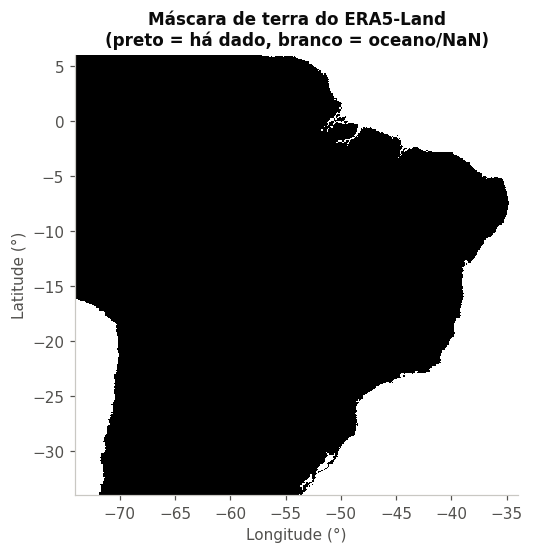

In [11]:
percentual_nan = float(np.isnan(ds["t2m"].isel(valid_time=0)).mean()) * 100
print("Pontos sem dado (oceano): %.1f%% da grade" % percentual_nan)

mascara = np.isfinite(ds["t2m"].isel(valid_time=0)).astype(float)

fig, ax = plt.subplots(figsize=(5.2, 5.2))
mascara.plot(ax=ax, cmap="Greys", add_colorbar=False)
ax.set_title("Máscara de terra do ERA5-Land\n(preto = há dado, branco = oceano/NaN)")
ax.set_xlabel("Longitude (°)"); ax.set_ylabel("Latitude (°)")
ax.grid(False)
plt.show()

In [12]:
# Caixa: Nordeste do Brasil

NORTE, SUL, OESTE, LESTE = -1, -18, -48, -34.5

recorte = dados.sel(latitude=slice(NORTE, SUL), longitude=slice(OESTE, LESTE))

print("Grade completa:", dict(dados.sizes))
print("Recorte       :", dict(recorte.sizes))
print("→ %.1f%% do tamanho original" % (100 * recorte["t2m_c"].size / dados["t2m_c"].size))
print()
print("Se inverter a ordem do slice:",
      dict(dados.sel(latitude=slice(SUL, NORTE)).sizes), "← latitude = 0, recorte vazio!")

Grade completa: {'valid_time': 12, 'latitude': 401, 'longitude': 401}
Recorte       : {'valid_time': 12, 'latitude': 170, 'longitude': 135}
→ 14.3% do tamanho original

Se inverter a ordem do slice: {'valid_time': 12, 'latitude': 0, 'longitude': 401} ← latitude = 0, recorte vazio!


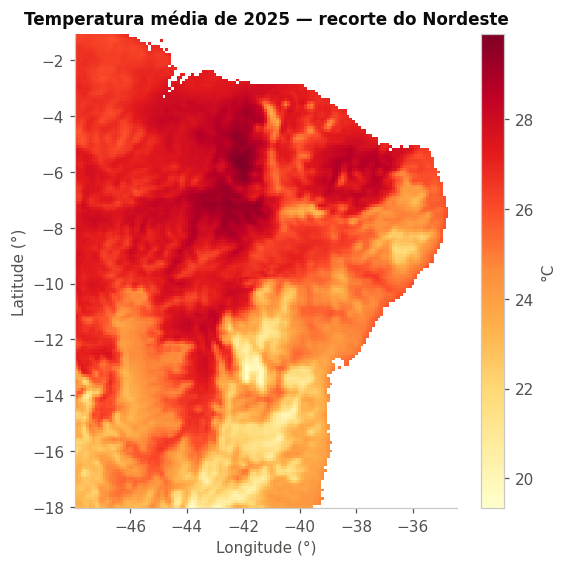

In [13]:
fig, ax = plt.subplots(figsize=(5.6, 5.6))
recorte["t2m_c"].mean("valid_time").plot(
    ax=ax, cmap=CMAP_TEMP, cbar_kwargs={"label": "°C"}
)
ax.set_title("Temperatura média de 2025 — recorte do Nordeste")
ax.set_xlabel("Longitude (°)"); ax.set_ylabel("Latitude (°)")
ax.grid(False)
plt.show()

### Recorte em um ponto

`method="nearest"` encontra o ponto de grade mais próximo das coordenadas pedidas. Como a grade é de
0,1°, o erro é de no máximo ~5 km — mas vale sempre conferir para onde você foi parar (e se caiu no mar).

In [14]:
CIDADES = {
    "Manaus":       (-3.10, -60.02),
    "Brasília":     (-15.79, -47.88),
    "Porto Alegre": (-30.03, -51.23),
}

series = {}
for nome, (lat, lon) in CIDADES.items():
    ponto = dados.sel(latitude=lat, longitude=lon, method="nearest")
    series[nome] = ponto
    print("%-13s pedido (%.2f, %.2f) → grade (%.2f, %.2f) | t2m média %.1f °C"
          % (nome, lat, lon,
             float(ponto.latitude), float(ponto.longitude),
             float(ponto["t2m_c"].mean())))

Manaus        pedido (-3.10, -60.02) → grade (-3.10, -60.00) | t2m média 26.9 °C
Brasília      pedido (-15.79, -47.88) → grade (-15.80, -47.90) | t2m média 22.2 °C
Porto Alegre  pedido (-30.03, -51.23) → grade (-30.00, -51.20) | t2m média 19.8 °C


In [15]:
# A série de um ponto vira uma tabela pandas com uma linha de comando
manaus = series["Manaus"][["t2m_c", "tp_mes", "vento"]].to_dataframe()
manaus = manaus.drop(columns=["number", "expver", "latitude", "longitude"], errors="ignore")
manaus.index = manaus.index.strftime("%Y-%m")
manaus.round(2)

,t2m_c,tp_mes,vento
valid_time,,,
2025-01,26.590000,197.95,1.01
2025-02,25.940001,491.56,1.10
2025-03,26.320000,323.56,1.15
2025-04,26.610001,290.81,0.75
2025-05,26.860001,192.97,0.85
2025-06,26.500000,155.56,1.07
2025-07,26.940001,57.54,0.72
2025-08,27.469999,88.89,0.81
2025-09,28.350000,72.95,0.48


## 9. Médias e somas

A força do xarray está em **reduzir por nome de dimensão**, não por número de eixo:

| Objetivo | Código | Resultado |
|---|---|---|
| Mapa da média do ano | `.mean("valid_time")` | mapa (lat × lon) |
| Série da média da região | `.mean(["latitude", "longitude"])` | série (tempo) |
| Total do ano em cada ponto | `.sum("valid_time")` | mapa (lat × lon) |
| Um único número | `.mean()` | escalar |

`NaN` é ignorado automaticamente em todas elas.

In [16]:
# 1) Médias/somas no tempo → mapas
temp_media_ano = dados["t2m_c"].mean("valid_time")
chuva_total_ano = dados["tp_mes"].sum("valid_time")

# 2) Médias no espaço → séries temporais
temp_serie = dados["t2m_c"].mean(["latitude", "longitude"])
chuva_serie = dados["tp_mes"].mean(["latitude", "longitude"])

print("Temperatura média do domínio em 2025 : %.2f °C" % float(temp_media_ano.mean()))
print("Chuva acumulada média em 2025        : %.0f mm" % float(chuva_total_ano.mean()))
print()
print("Mês mais quente : %s (%.2f °C)"
      % (temp_serie.idxmax().dt.strftime("%Y-%m").item(), float(temp_serie.max())))
print("Mês mais frio   : %s (%.2f °C)"
      % (temp_serie.idxmin().dt.strftime("%Y-%m").item(), float(temp_serie.min())))
print("Mês mais chuvoso: %s (%.0f mm)"
      % (chuva_serie.idxmax().dt.strftime("%Y-%m").item(), float(chuva_serie.max())))

Temperatura média do domínio em 2025 : 23.09 °C
Chuva acumulada média em 2025        : 1143 mm

Mês mais quente : 2025-02 (24.79 °C)
Mês mais frio   : 2025-06 (20.41 °C)
Mês mais chuvoso: 2025-01 (198 mm)


### Soma: cuidado com o que se pode somar

* **Precipitação** é um *acumulado* → somar os 12 meses faz sentido (total do ano).
* **Temperatura** é um *estado instantâneo* → somar não significa nada; use média.

Por isso `tp_mes` (mm de cada mês) é o campo certo para somar, e não `tp_dia`.

In [18]:
# Comparando o total anual em cada cidade
resumo = pd.DataFrame({
    nome: {
        "temp. média (°C)": float(p["t2m_c"].mean()),
        "temp. mín. mensal (°C)": float(p["t2m_c"].min()),
        "temp. máx. mensal (°C)": float(p["t2m_c"].max()),
        "chuva no ano (mm)": float(p["tp_mes"].sum()),
        "vento médio (m/s)": float(p["vento"].mean()),
    }
    for nome, p in series.items()
}).T
resumo.round(1)

,temp. média (°C),temp. mín. mensal (°C),temp. máx. mensal (°C),chuva no ano (mm),vento médio (m/s)
Manaus,26.9,25.9,28.4,2705.6,0.8
Brasília,22.2,19.6,24.1,925.4,1.4
Porto Alegre,19.8,12.7,26.5,1499.2,1.0


## 10. Mapas

`DataArray.plot()` já desenha o mapa sozinho: escolhe o tipo de gráfico pelo número de dimensões,
rotula os eixos e a barra de cores com os `attrs`.

**Sobre a escala de cores:**

* **magnitude** (temperatura absoluta, chuva) → escala **sequencial**, de claro a escuro, uma família
  de cor só (`YlOrRd`, `Blues`);
* **anomalia** (desvio em torno de zero) → escala **divergente**, duas cores opostas com neutro no
  meio (`RdBu_r`);
* evite arco-íris (`jet`, `rainbow`): cria fronteiras que não existem no dado e é ruim para daltônicos.

**E um truque que salva mapas:** `robust=True` corta a escala nos percentis 2 e 98. Sem ele, os
−19 °C dos Andes e os 9.000 mm da Colômbia esticam a barra de cores e o Brasil inteiro vira uma
mancha de cor só. (Para fixar a escala na mão, use `vmin=` e `vmax=`.)

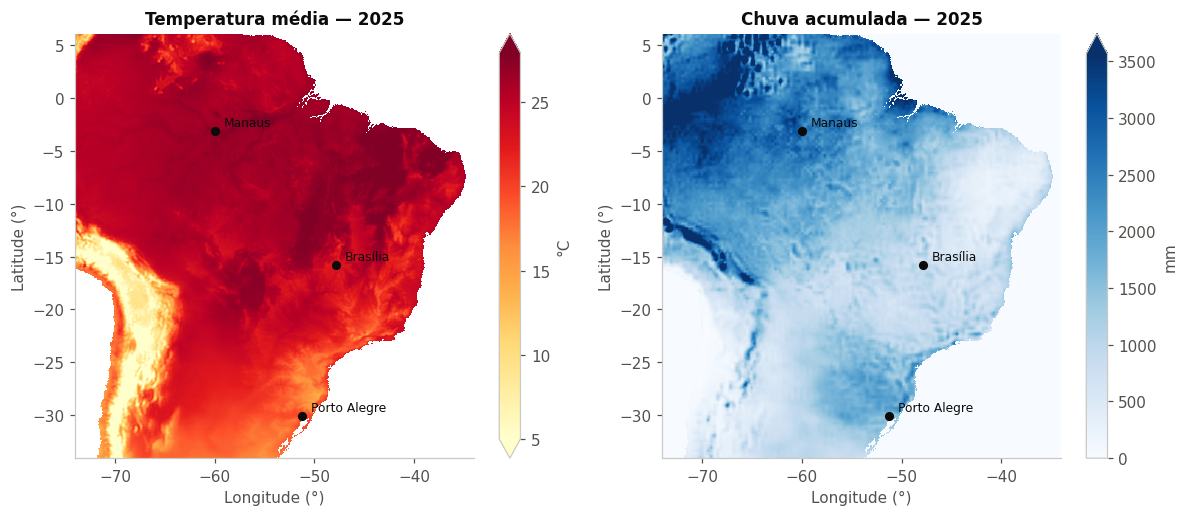

In [19]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4.8))

temp_media_ano.plot(ax=eixos[0], cmap=CMAP_TEMP, robust=True, cbar_kwargs={"label": "°C"})
eixos[0].set_title("Temperatura média — 2025")

chuva_total_ano.plot(ax=eixos[1], cmap=CMAP_CHUVA, robust=True, cbar_kwargs={"label": "mm"})
eixos[1].set_title("Chuva acumulada — 2025")

for ax in eixos:
    ax.set_xlabel("Longitude (°)"); ax.set_ylabel("Latitude (°)")
    ax.grid(False)
    for nome, (lat, lon) in CIDADES.items():
        ax.plot(lon, lat, marker="o", markersize=5, color="#0b0b0b")
        ax.annotate(nome, (lon, lat), textcoords="offset points", xytext=(6, 3), fontsize=8)

plt.tight_layout()
plt.show()

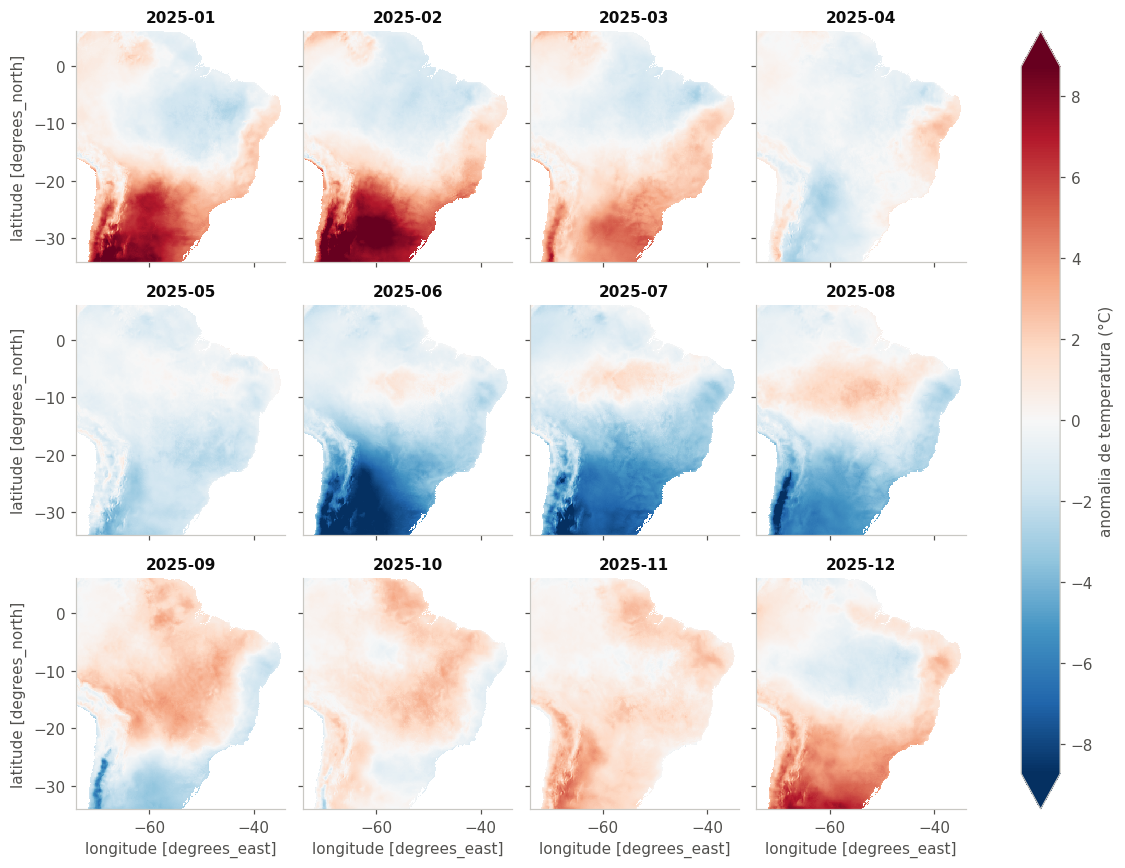

In [20]:
# Anomalia: cada mês menos a média do ano → escala divergente, centrada em zero
anomalia = dados["t2m_c"] - temp_media_ano
limite = float(abs(anomalia).quantile(0.99))

grade = anomalia.plot(
    col="valid_time", col_wrap=4, figsize=(11, 8),
    cmap=CMAP_ANOM, vmin=-limite, vmax=limite,
    cbar_kwargs={"label": "anomalia de temperatura (°C)"},
)
for ax, rotulo in zip(grade.axs.flat, dados["valid_time"].dt.strftime("%Y-%m").values):
    ax.set_title(rotulo, fontsize=10)
    ax.grid(False)
plt.show()

## 11. Exportar para GeoTIFF (`.tif`)

Para levar o dado a um SIG (QGIS, ArcGIS) o formato natural é o **GeoTIFF**. O `rioxarray` faz a ponte,
e são três passos obrigatórios:

1. **`set_spatial_dims`** — dizer quais dimensões são x e y (aqui elas se chamam `longitude`/`latitude`);
2. **`write_crs("EPSG:4326")`** — declarar o sistema de coordenadas (graus, WGS84);
3. **`write_nodata(np.nan)`** — marcar o "sem dado", senão o oceano vira uma mancha de zeros.

Um `DataArray` **2D** vira um `.tif` de **uma banda**; um **3D** vira um `.tif` **multibanda**
(uma banda por mês).

In [21]:
def para_geotiff(da, caminho):
    """Grava um DataArray (lat/lon) como GeoTIFF em EPSG:4326."""
    saida = (
        da.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")
          .rio.write_crs("EPSG:4326")
          .rio.write_nodata(np.nan)
    )
    saida.rio.to_raster(caminho)
    print("gravado: %s (%.1f KB)" % (caminho, caminho.stat().st_size / 1024))
    return caminho

tif_temp = para_geotiff(temp_media_ano, SAIDAS / "t2m_media_2025.tif")
tif_chuva = para_geotiff(chuva_total_ano, SAIDAS / "chuva_total_2025.tif")
tif_mensal = para_geotiff(dados["t2m_c"], SAIDAS / "t2m_mensal_2025.tif")  # 12 bandas

gravado: saidas/t2m_media_2025.tif (629.2 KB)
gravado: saidas/chuva_total_2025.tif (1258.0 KB)
gravado: saidas/t2m_mensal_2025.tif (7541.5 KB)


## 12. Ler e visualizar o `.tif`

`rioxarray.open_rasterio()` devolve um `DataArray` com uma dimensão `band` e as coordenadas já em
`x`/`y`. Use `masked=True` para que o *nodata* volte como `NaN`.

Repare que o eixo agora se chama `x`/`y` (convenção de raster), e não mais `longitude`/`latitude`.

In [22]:
raster = rioxarray.open_rasterio(tif_temp, masked=True)

print("Formato        :", raster.shape, "(banda, y, x)")
print("CRS            :", raster.rio.crs)
print("Resolução      :", raster.rio.resolution(), "graus")
print("Nodata         :", raster.rio.nodata)
print("Tipo           :", raster.dtype)
print("Extensão (bbox):", tuple(round(v, 2) for v in raster.rio.bounds()))
print()
print("Transform (afim):")
print(raster.rio.transform())

Formato        : (1, 401, 401) (banda, y, x)
CRS            : EPSG:4326
Resolução      : (0.1, -0.1) graus
Nodata         : nan
Tipo           : float32
Extensão (bbox): (-74.05, -34.05, -33.95, 6.05)

Transform (afim):
| 0.10, 0.00,-74.05|
| 0.00,-0.10, 6.05|
| 0.00, 0.00, 1.00|


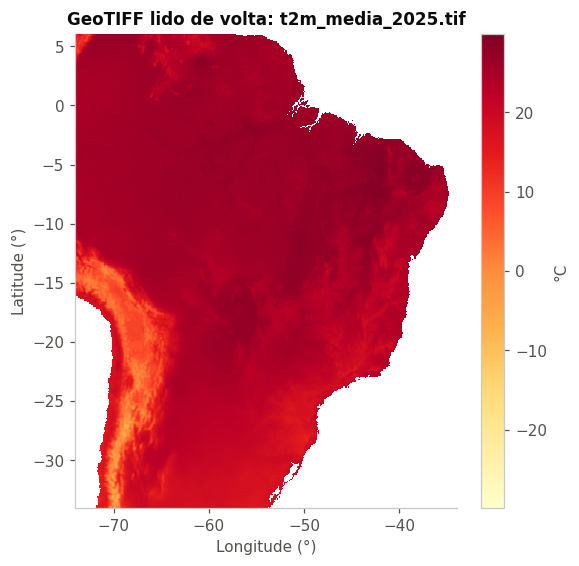

In [23]:
fig, ax = plt.subplots(figsize=(5.6, 5.6))
raster.squeeze().plot(ax=ax, cmap=CMAP_TEMP, cbar_kwargs={"label": "°C"})
ax.set_title("GeoTIFF lido de volta: t2m_media_2025.tif")
ax.set_xlabel("Longitude (°)"); ax.set_ylabel("Latitude (°)")
ax.grid(False)
plt.show()

bandas: 12


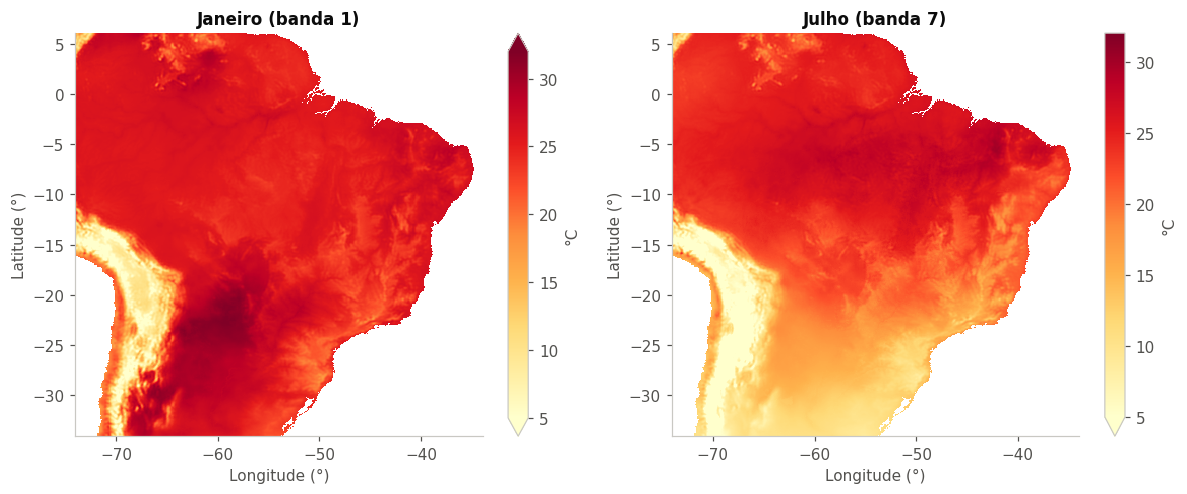

In [24]:
# No arquivo multibanda, cada banda é um mês — banda 1 = janeiro, banda 7 = julho
mensal = rioxarray.open_rasterio(tif_mensal, masked=True)
print("bandas:", int(mensal.sizes["band"]))

fig, eixos = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, banda, titulo in zip(eixos, [1, 7], ["Janeiro (banda 1)", "Julho (banda 7)"]):
    mensal.sel(band=banda).plot(ax=ax, cmap=CMAP_TEMP, vmin=5, vmax=32,
                                cbar_kwargs={"label": "°C"})
    ax.set_title(titulo)
    ax.set_xlabel("Longitude (°)"); ax.set_ylabel("Latitude (°)")
    ax.grid(False)
plt.tight_layout()
plt.show()

> **Dica de SIG:** esses `.tif` abrem direto no QGIS (arraste o arquivo para a janela). Como já têm
> CRS declarado, entram no lugar certo do mapa sem nenhuma configuração extra.

## 13. Séries temporais

Agora os gráficos que respondem "como isso variou ao longo do ano?". A receita é sempre a mesma:
**reduzir até sobrar só a dimensão do tempo** e desenhar.

Regras que valem para qualquer gráfico de série:

* uma linha por entidade, **rótulo direto** no fim da linha (além da legenda);
* **um eixo y só** — nunca dois eixos com escalas diferentes no mesmo gráfico; se as unidades são
  diferentes, faça dois gráficos;
* grade discreta, sem moldura pesada.

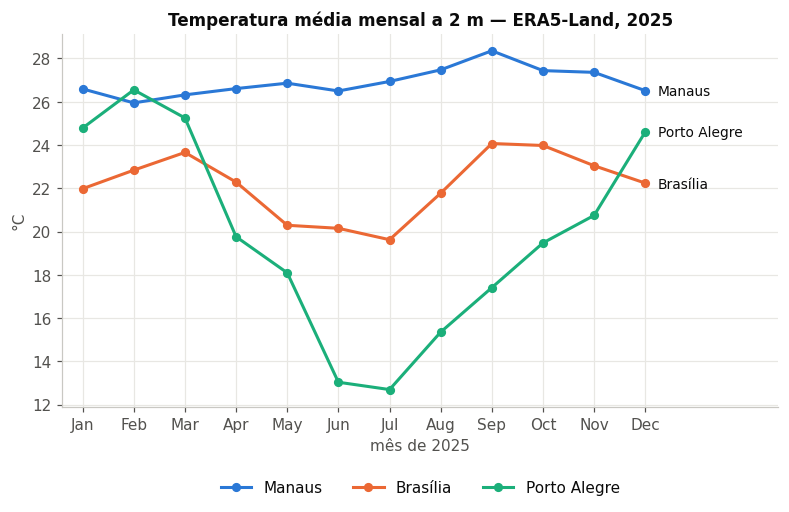

,Manaus,Brasília,Porto Alegre
2025-01,26.600000,22.000000,24.799999
2025-02,25.900000,22.799999,26.500000
2025-03,26.299999,23.700001,25.200001
2025-04,26.600000,22.299999,19.799999
2025-05,26.900000,20.299999,18.100000
2025-06,26.500000,20.100000,13.000000
2025-07,26.900000,19.600000,12.700000
2025-08,27.500000,21.799999,15.400000
2025-09,28.400000,24.100000,17.400000
2025-10,27.400000,24.000000,19.500000


In [25]:
meses = dados["valid_time"].dt.strftime("%b").values          # Jan, Feb, ...
rotulos = dados["valid_time"].dt.strftime("%Y-%m").values

fig, ax = plt.subplots(figsize=(8.4, 4.4))
for (nome, ponto), cor in zip(series.items(), CORES):
    y = ponto["t2m_c"].values
    ax.plot(meses, y, color=cor, marker="o", label=nome)
    ax.annotate(nome, (len(meses) - 1, y[-1]), textcoords="offset points",
                xytext=(8, -3), fontsize=9, color="#0b0b0b")

ax.set_title("Temperatura média mensal a 2 m — ERA5-Land, 2025")
ax.set_ylabel("°C"); ax.set_xlabel("mês de 2025")
ax.set_xlim(-0.4, len(meses) + 1.6)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3)
plt.show()

# a "visão de tabela" do mesmo gráfico
pd.DataFrame({n: p["t2m_c"].values for n, p in series.items()}, index=rotulos).round(1)

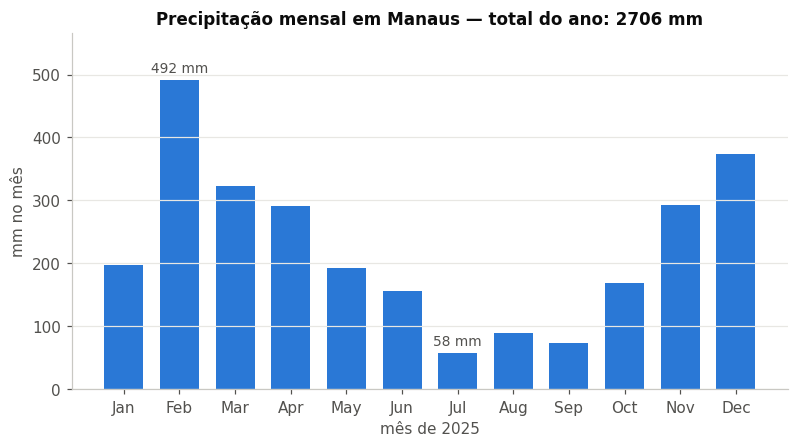

,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
chuva no mês (mm),198.0,492.0,324.0,291.0,193.0,156.0,58.0,89.0,73.0,168.0,292.0,374.0


In [26]:
# Chuva mensal de uma cidade: acumulado → barras (uma série, uma cor)
cidade = "Manaus"
chuva = series[cidade]["tp_mes"].values

fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.bar(meses, chuva, width=0.7, color=CORES[0])
# rótulo só nos extremos: número em cima de toda barra polui o gráfico
for x in (int(chuva.argmax()), int(chuva.argmin())):
    ax.annotate("%.0f mm" % chuva[x], (x, chuva[x]), textcoords="offset points",
                xytext=(0, 5), ha="center", fontsize=9, color="#52514e")

ax.set_title("Precipitação mensal em %s — total do ano: %.0f mm" % (cidade, chuva.sum()))
ax.set_ylabel("mm no mês"); ax.set_xlabel("mês de 2025")
ax.set_ylim(0, chuva.max() * 1.15)
ax.grid(axis="x", visible=False)
plt.show()

pd.DataFrame({"chuva no mês (mm)": chuva.round(0)}, index=rotulos).T

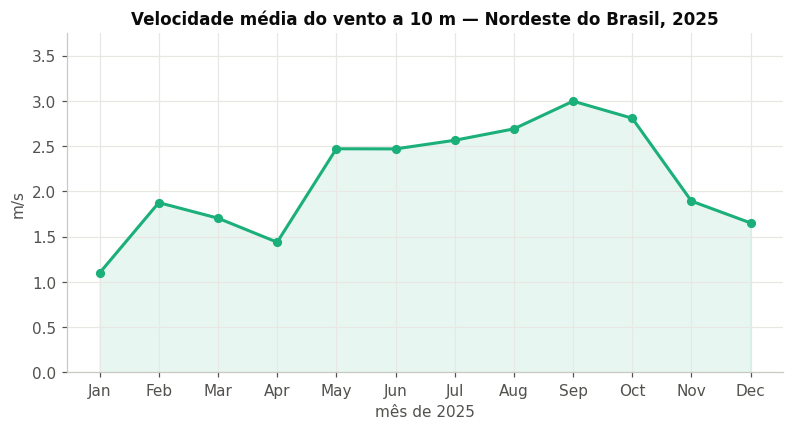

Mês mais ventoso: 2025-09 (3.00 m/s)


In [27]:
# Vento: média espacial do recorte do Nordeste, mês a mês
vento_ne = recorte["vento"].mean(["latitude", "longitude"])

fig, ax = plt.subplots(figsize=(8.4, 4.0))
ax.plot(meses, vento_ne.values, color=CORES[2], marker="o")
ax.fill_between(range(len(meses)), vento_ne.values, color=CORES[2], alpha=0.10)
ax.set_title("Velocidade média do vento a 10 m — Nordeste do Brasil, 2025")
ax.set_ylabel("m/s"); ax.set_xlabel("mês de 2025")
ax.set_ylim(0, float(vento_ne.max()) * 1.25)
plt.show()

print("Mês mais ventoso: %s (%.2f m/s)"
      % (vento_ne.idxmax().dt.strftime("%Y-%m").item(), float(vento_ne.max())))

### Comparando o ciclo anual de temperatura e chuva

Temperatura (°C) e chuva (mm) têm escalas diferentes. Em vez de dois eixos y no mesmo gráfico —
que distorce a leitura, porque a posição relativa das curvas depende de uma escolha arbitrária de
escala — use **dois painéis empilhados** com o mesmo eixo x.

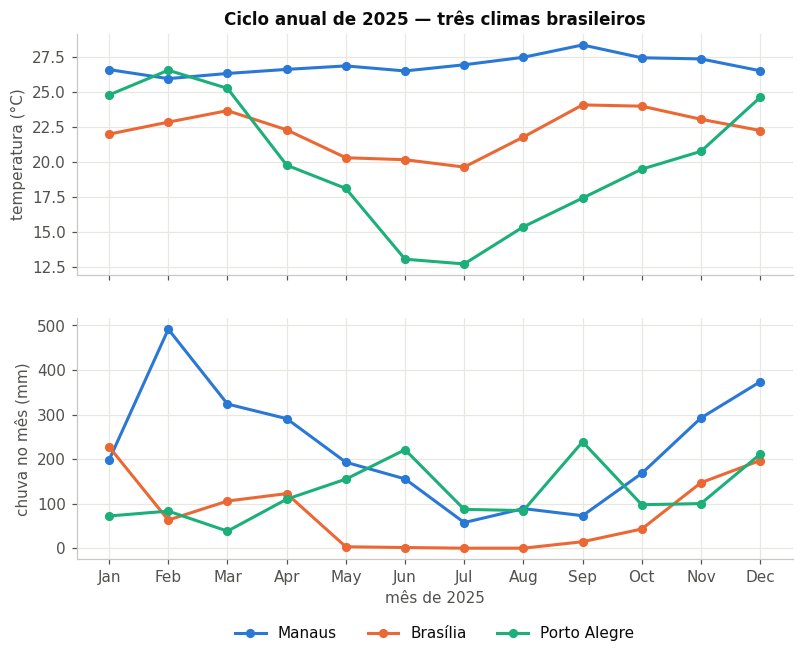

In [28]:
fig, (topo, base) = plt.subplots(2, 1, figsize=(8.4, 6.2), sharex=True,
                                 gridspec_kw={"height_ratios": [1, 1], "hspace": 0.18})

for (nome, ponto), cor in zip(series.items(), CORES):
    topo.plot(meses, ponto["t2m_c"].values, color=cor, marker="o", label=nome)
    base.plot(meses, ponto["tp_mes"].values, color=cor, marker="o", label=nome)

topo.set_title("Ciclo anual de 2025 — três climas brasileiros")
topo.set_ylabel("temperatura (°C)")
base.set_ylabel("chuva no mês (mm)")
base.set_xlabel("mês de 2025")
base.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3)
plt.show()

## 14. Exportar os resultados

Duas saídas resolvem quase tudo:

* **CSV** para séries pontuais (abre no Excel, no R, em qualquer lugar) — via `.to_dataframe()`;
* **NetCDF** para o recorte espacial, preservando coordenadas, unidades e metadados — via `.to_netcdf()`.

In [29]:
# 1) CSV com a série das três cidades
tabela_cidades = pd.concat(
    {nome: p[["t2m_c", "tp_mes", "vento"]].to_dataframe()
             .drop(columns=["number", "expver", "latitude", "longitude"], errors="ignore")
     for nome, p in series.items()},
    names=["cidade"],
).round(3)
csv = SAIDAS / "series_cidades_2025.csv"
tabela_cidades.to_csv(csv)

# 2) NetCDF com o recorte do Nordeste, já em unidades práticas
nc = SAIDAS / "recorte_nordeste_2025.nc"
recorte.to_netcdf(nc)

print("Arquivos gerados em ./%s:" % SAIDAS)
for arquivo in sorted(SAIDAS.iterdir()):
    print("  %-28s %8.1f KB" % (arquivo.name, arquivo.stat().st_size / 1024))

tabela_cidades.head(4)

Arquivos gerados em ./saidas:
  chuva_total_2025.tif           1258.0 KB
  recorte_nordeste_2025.nc       6478.2 KB
  series_cidades_2025.csv           1.5 KB
  t2m_media_2025.tif              629.2 KB
  t2m_mensal_2025.tif            7541.5 KB


t2m_c   tp_mes  vento
cidade valid_time                           
Manaus 2025-01-01  26.591000  197.951  1.010
       2025-02-01  25.945000  491.560  1.098
       2025-03-01  26.316000  323.561  1.148
       2025-04-01  26.606001  290.808  0.748